# 3. Classification

This notebook explores:
- Feature importance.
- Building classification models (Random Forest, SVM, etc.).
- Performance metrics (Precision, Recall, F1-score).

Target: customer_segment
customer_segment
VIP          5149
Returning    4285
New           566
Name: count, dtype: int64

Best Params: {'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}

===== RESULTS =====
Accuracy : 0.303
Precision: 0.44265943184889806
Recall   : 0.303
F1 Score : 0.3441607252397237
Log Loss : 1.1014222721915434

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         New       0.04      0.28      0.08       113
   Returning       0.43      0.38      0.40       857
         VIP       0.50      0.24      0.33      1030

    accuracy                           0.30      2000
   macro avg       0.32      0.30      0.27      2000
weighted avg       0.44      0.30      0.34      2000



<Figure size 600x500 with 0 Axes>

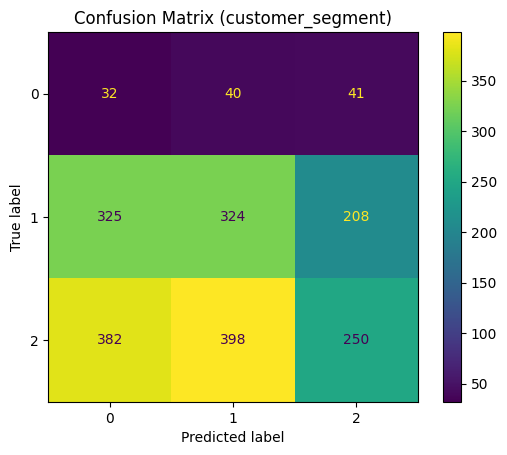


===== CROSS VALIDATION =====
F1 Scores: [0.34302665 0.32404206 0.33823064 0.37024886 0.34094555]
Mean F1 : 0.34329874937586763

✅ Model saved: customer_segment_model.joblib


In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    accuracy_score, precision_score, recall_score, f1_score, log_loss
)

# =====================================================
# 1. LOAD DATA
# =====================================================
df = pd.read_csv("../data/cleaned_data.csv")

# =====================================================
# 🔥 2. SELECT TARGET COLUMN
# =====================================================
# CHANGE HERE 👇
target_col = "customer_segment"
# target_col = "delivery_status"

# =====================================================
# 3. DEFINE FEATURES & TARGET
# =====================================================
X = df.drop(columns=[target_col])
y = df[target_col]

print("Target:", target_col)
print(y.value_counts())

# =====================================================
# 4. TRAIN TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 5. IDENTIFY COLUMN TYPES
# =====================================================
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

# =====================================================
# 6. PREPROCESSING
# =====================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# =====================================================
# 7. MODEL (SOFTMAX / MULTINOMIAL LOGISTIC)
# =====================================================
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

# =====================================================
# 8. HYPERPARAMETER TUNING
# =====================================================
param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__solver": ["lbfgs", "saga"]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Params:", grid.best_params_)

# =====================================================
# 9. PREDICTION
# =====================================================
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

# =====================================================
# 10. EVALUATION
# =====================================================
print("\n===== RESULTS =====")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

print("Log Loss :", log_loss(y_test, y_proba))

# =====================================================
# 11. CLASSIFICATION REPORT
# =====================================================
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# =====================================================
# 12. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix ({target_col})")
plt.show()

# =====================================================
# 13. CROSS VALIDATION
# =====================================================
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)

print("\n===== CROSS VALIDATION =====")
print("F1 Scores:", cv_scores)
print("Mean F1 :", cv_scores.mean())

# =====================================================
# 14. SAVE MODEL
# =====================================================
os.makedirs("../artifacts/", exist_ok=True)

joblib.dump(best_model, f"../artifacts/{target_col}_model.joblib")

print(f"\n✅ Model saved: {target_col}_model.joblib")